In [7]:
#通过数据效用曲线来评估数据量的影响
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tabpfn_extensions.post_hoc_ensembles.sklearn_interface import AutoTabPFNRegressor

maccs_df = pd.read_excel('categorized_maccs.xlsx', sheet_name='Sheet1', header=0)
X = maccs_df.filter(regex='MACCS_\d+')
y = maccs_df['logkOH•']

constant_cols = X.columns[X.nunique() == 1]
X = X.drop(columns=constant_cols)
# 提取分层采样依据列
stratify_column = maccs_df['chemical class-98']

# 固定测试集（全量数据的20%）
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

In [8]:
def create_missing_data(X, missing_rate):
    """生成指定缺失比例的数据"""
    mask = np.random.choice([True, False], size=X.shape, p=[missing_rate, 1-missing_rate])
    return pd.DataFrame(np.where(mask, np.nan, X), columns=X.columns)

rate = 0.05
X_train_missing = create_missing_data(X_train, rate)
X_test_missing = create_missing_data(X_test, rate)

# 训练模型
model = AutoTabPFNRegressor(
    device='cuda'
).fit(X_train_missing, y_train)

# 预测并计算RMSE（直接使用sklearn的squared=False参数）
y_pred = model.predict(X_test_missing)
rmse = mean_squared_error(y_test, y_pred, squared=False)
print(rmse)

2025-06-30 15:28:03 INFO     Using `default` preset for Post Hoc Ensemble.
2025-06-30 15:28:03 INFO     No categorical_feature_indices given. Assuming no categorical features.
2025-06-30 15:28:03 INFO     Using task type: regression
2025-06-30 15:28:03 INFO     Obtaining TabPFN models from a random portfolio.
2025-06-30 15:28:11 INFO     Using 100 base models: ['default_tabpfn_model_0', 'random_tabpfn_model_1', 'random_tabpfn_model_2', 'random_tabpfn_model_3', 'random_tabpfn_model_4', 'random_tabpfn_model_5', 'random_tabpfn_model_6', 'random_tabpfn_model_7', 'random_tabpfn_model_8', 'random_tabpfn_model_9', 'random_tabpfn_model_10', 'random_tabpfn_model_11', 'random_tabpfn_model_12', 'random_tabpfn_model_13', 'random_tabpfn_model_14', 'random_tabpfn_model_15', 'random_tabpfn_model_16', 'random_tabpfn_model_17', 'random_tabpfn_model_18', 'random_tabpfn_model_19', 'random_tabpfn_model_20', 'random_tabpfn_model_21', 'random_tabpfn_model_22', 'random_tabpfn_model_23', 'random_tabpfn_model_

0.32832049846252054


C:\Users\work\miniconda3\envs\tabpfn\lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [9]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['axes.unicode_minus'] = False

PermutationExplainer explainer: 219it [11:38,  3.25s/it]                         


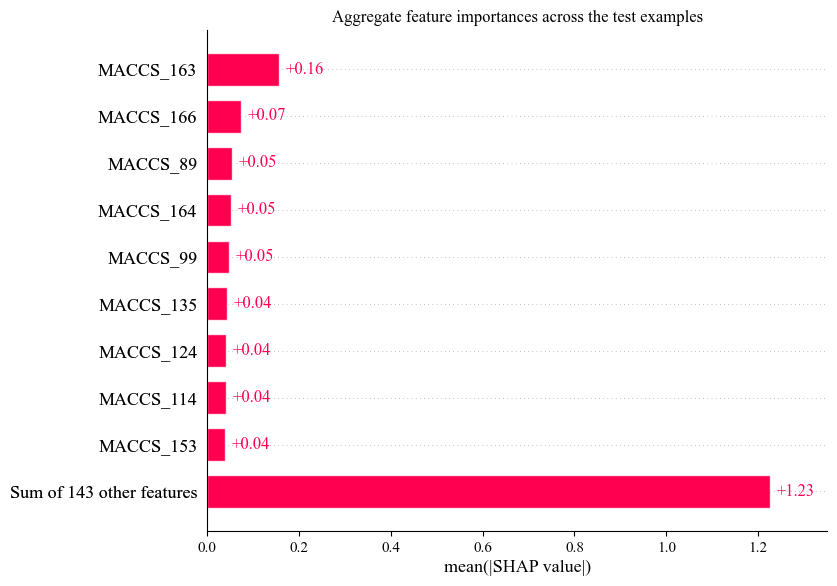

C:\Users\work\tabpfn-extensions\src\tabpfn_extensions\interpretability\shap.py:60: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values=shap_values, show=False)


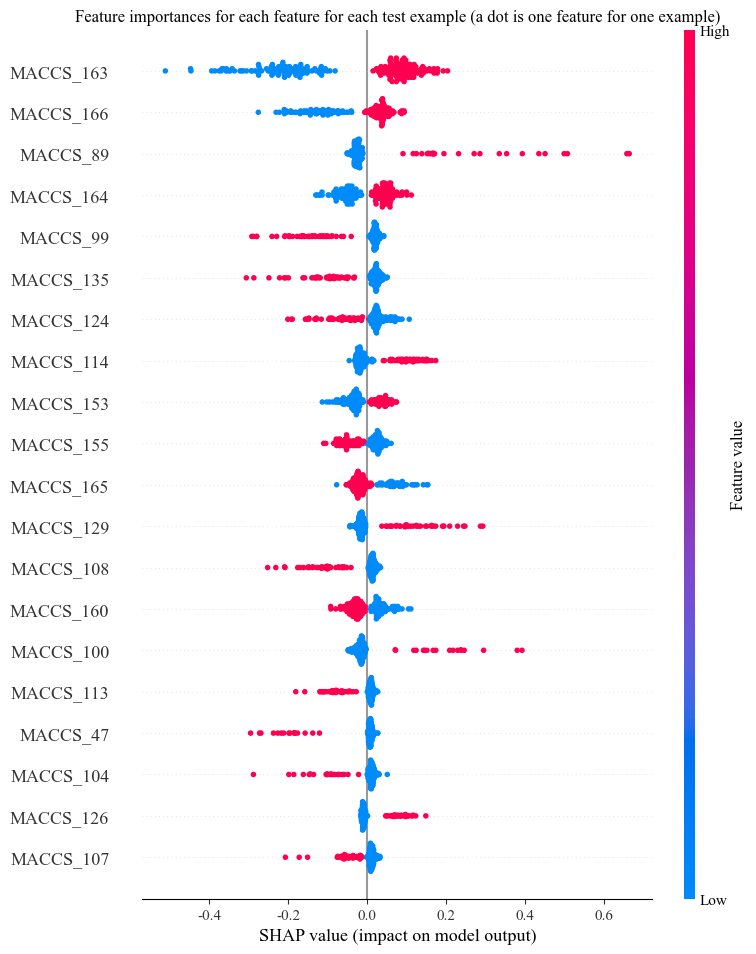

Now we analyze the strongest feature interactions of the most important feature, namely the feature "148".


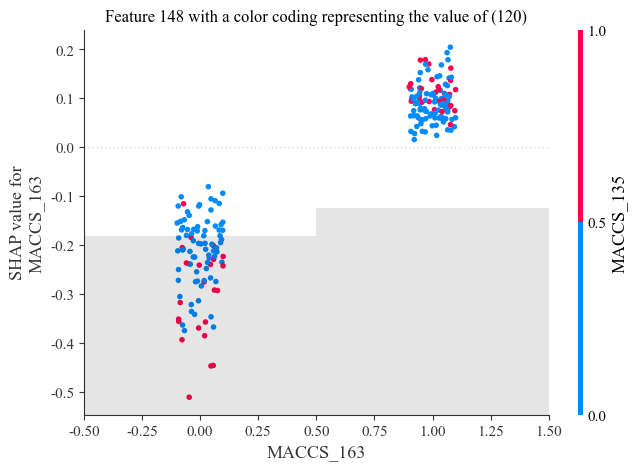

In [10]:
from tabpfn_extensions import interpretability

feature_names = X.columns

shap_values = interpretability.shap.get_shap_values(
    estimator=model,
    test_x=X_test,
    attribute_names=feature_names,
    algorithm="permutation",
)

fig = interpretability.shap.plot_shap(shap_values)

In [11]:
import shap
plt.figure(figsize=(10, 5), dpi=1200)
shap.summary_plot(shap_values, X, plot_type="bar", show=False,max_display=13)
plt.savefig("1_missing_value_5.pdf", format='pdf',bbox_inches='tight',dpi=1200)
plt.tight_layout()
plt.show()

C:\Users\work\AppData\Local\Temp\ipykernel_10728\2356495678.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X, plot_type="bar", show=False,max_display=13)


C:\Users\work\AppData\Local\Temp\ipykernel_10728\2903691569.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, feature_names=feature_names, plot_type="dot", show=False, color='coolwarm',max_display=13)


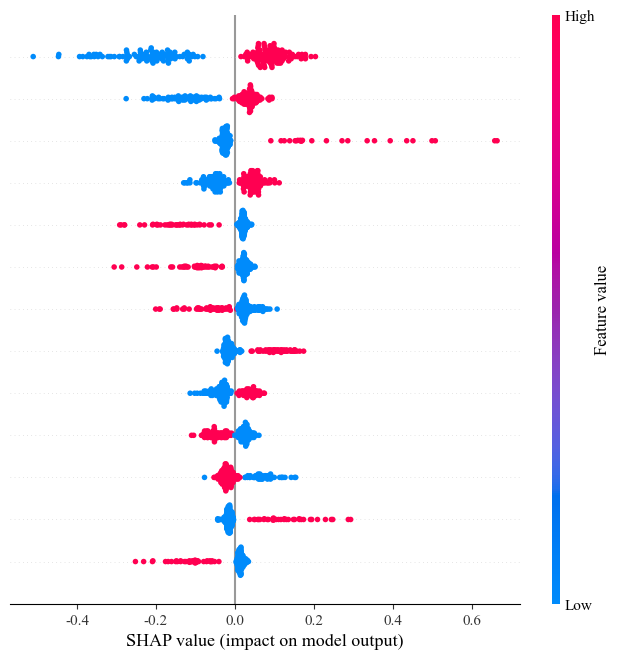

In [12]:
plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=feature_names, plot_type="dot", show=False, color='coolwarm',max_display=13)
# 获取当前坐标轴，并关闭y轴显示
plt.gca().get_yaxis().set_visible(False)
plt.savefig("2_missing_value_5.pdf", format='pdf',bbox_inches='tight',dpi=1200)
plt.show()